# Pixel DDPM vs Latent Diffusion on MNIST

This notebook compares two small diffusion pipelines on MNIST:

1. **Normal / pixel-space diffusion**  
   A denoising U-Net is trained directly on images.

2. **Latent diffusion**  
   A compact autoencoder first maps images into a lower-dimensional latent tensor.  
   A second denoising U-Net is trained in that latent space, then sampled latents are decoded back to images.

## 0. Setup

If needed, install the dependencies:

```bash
pip install torch torchvision matplotlib tqdm
```

The notebook pads MNIST from `28x28` to `32x32`, because powers-of-two spatial sizes make both the pixel U-Net and the latent U-Net cleaner.

In [1]:
from __future__ import annotations

import math
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Optional

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.7.0+cu126
cuda available: True


In [2]:
@dataclass
class CFG:
    seed: int = 42

    # Data
    data_dir: str = "./data"
    image_size: int = 32
    batch_size: int = 256
    num_workers: int = 0

    # Diffusion
    timesteps: int = 300
    beta_start: float = 1e-4
    beta_end: float = 2e-2

    # Training
    lr: float = 2e-4
    epochs_pixel: int = 8
    epochs_autoencoder: int = 8
    epochs_latent: int = 10
    grad_clip: float = 1.0
    use_amp: bool = True

    # Model sizes
    pixel_unet_base_ch: int = 64
    latent_unet_base_ch: int = 64
    ae_base_ch: int = 32
    latent_ch: int = 4

    # Sampling
    n_samples: int = 64

    # IO
    out_dir: str = "./mnist_pixel_vs_ldm"


cfg = CFG()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg.use_amp = bool(cfg.use_amp and DEVICE.type == "cuda")

Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)

def seed_everything(seed: int) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

print(cfg)
print("device:", DEVICE)
print("AMP:", cfg.use_amp)

CFG(seed=42, data_dir='./data', image_size=32, batch_size=256, num_workers=0, timesteps=300, beta_start=0.0001, beta_end=0.02, lr=0.0002, epochs_pixel=8, epochs_autoencoder=8, epochs_latent=10, grad_clip=1.0, use_amp=True, pixel_unet_base_ch=64, latent_unet_base_ch=64, ae_base_ch=32, latent_ch=4, n_samples=64, out_dir='./mnist_pixel_vs_ldm')
device: cuda
AMP: True


## 1. MNIST dataloader

Images are normalized to `[-1, 1]`, which matches the `tanh` decoder output and is convenient for diffusion training.

batch: torch.Size([256, 1, 32, 32]) -1.0 1.0


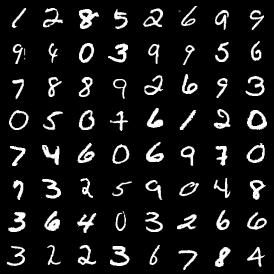

In [3]:
transform = transforms.Compose([
    transforms.Pad(2),  # 28x28 -> 32x32
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),  # [0,1] -> [-1,1]
])

train_ds = datasets.MNIST(
    root=cfg.data_dir,
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

x, y = next(iter(train_loader))
print("batch:", x.shape, x.min().item(), x.max().item())

def to_display_grid(x: torch.Tensor, nrow: int = 8) -> Image.Image:
    """Convert a [-1,1] image batch to a PIL grid."""
    x = x.detach().cpu().clamp(-1, 1)
    x = (x + 1) / 2
    grid = make_grid(x, nrow=nrow)
    grid = transforms.ToPILImage()(grid)
    return grid

display(to_display_grid(x[:64]))

## 2. Diffusion utilities

The forward process is:

$$
q(x_t \mid x_0) = \mathcal{N}(\sqrt{\bar{\alpha}_t}x_0,\ (1-\bar{\alpha}_t)I)
$$

The denoising network learns to predict the sampled noise:

$$
\epsilon_\theta(x_t, t) \approx \epsilon
$$

For the pixel model, `x` is an image tensor.  
For the latent model, `x` is an encoded latent tensor.

In [4]:
class DiffusionSchedule:
    def __init__(
        self,
        timesteps: int,
        beta_start: float = 1e-4,
        beta_end: float = 2e-2,
        device: torch.device | str = "cpu",
    ):
        self.timesteps = timesteps
        self.device = torch.device(device)

        betas = torch.linspace(beta_start, beta_end, timesteps, device=self.device)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

        self.betas = betas
        self.alphas = alphas
        self.alpha_bars = alpha_bars
        self.alpha_bars_prev = alpha_bars_prev

        self.sqrt_alpha_bars = torch.sqrt(alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

        self.posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

    def extract(self, values: torch.Tensor, t: torch.Tensor, x_shape: tuple[int, ...]) -> torch.Tensor:
        """Extract values[t] and reshape for broadcasting over x."""
        out = values.gather(0, t)
        return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(
    x0: torch.Tensor,
    t: torch.Tensor,
    schedule: DiffusionSchedule,
    noise: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """Sample x_t directly from q(x_t | x_0)."""
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_ab = schedule.extract(schedule.sqrt_alpha_bars, t, x0.shape)
    sqrt_one_minus_ab = schedule.extract(schedule.sqrt_one_minus_alpha_bars, t, x0.shape)
    return sqrt_ab * x0 + sqrt_one_minus_ab * noise


schedule = DiffusionSchedule(
    timesteps=cfg.timesteps,
    beta_start=cfg.beta_start,
    beta_end=cfg.beta_end,
    device=DEVICE,
)

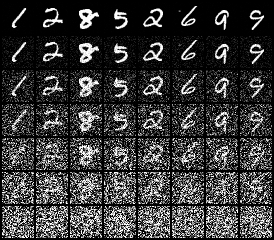

In [5]:
# Visualize the forward noising process on real MNIST images.
with torch.no_grad():
    x0 = x[:8].to(DEVICE)
    selected_t = torch.tensor([0, 25, 75, 125, 175, 225, 299], device=DEVICE).long()

    rows = []
    for t_value in selected_t:
        t = torch.full((x0.shape[0],), int(t_value.item()), device=DEVICE).long()
        xt = q_sample(x0, t, schedule)
        rows.append(xt.cpu())

    forward_grid = torch.cat(rows, dim=0)

display(to_display_grid(forward_grid, nrow=8))

## 3. Shared U-Net denoiser

This is a deliberately small U-Net:

- sinusoidal time embedding,
- residual blocks with time conditioning,
- two downsampling stages,
- two upsampling stages.

The same architecture is used for both image tensors and latent tensors. Only the number of input channels changes.

In [6]:
def valid_group_count(channels: int, max_groups: int = 8) -> int:
    """Choose a GroupNorm group count that divides channels."""
    for g in reversed(range(1, max_groups + 1)):
        if channels % g == 0:
            return g
    return 1


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        device = t.device
        scale = math.log(10000) / max(half - 1, 1)
        freqs = torch.exp(torch.arange(half, device=device) * -scale)
        args = t.float()[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int, dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.GroupNorm(valid_group_count(in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch),
        )

        self.norm2 = nn.GroupNorm(valid_group_count(out_ch), out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.skip(x)


class TinyUNet(nn.Module):
    def __init__(self, in_ch: int = 1, base_ch: int = 64, time_dim: int = 256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init = nn.Conv2d(in_ch, base_ch, kernel_size=3, padding=1)

        self.down1 = ResBlock(base_ch, base_ch, time_dim)
        self.downsample1 = nn.Conv2d(base_ch, base_ch * 2, kernel_size=4, stride=2, padding=1)

        self.down2 = ResBlock(base_ch * 2, base_ch * 2, time_dim)
        self.downsample2 = nn.Conv2d(base_ch * 2, base_ch * 4, kernel_size=4, stride=2, padding=1)

        self.mid1 = ResBlock(base_ch * 4, base_ch * 4, time_dim)
        self.mid2 = ResBlock(base_ch * 4, base_ch * 4, time_dim)

        self.upsample1 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=4, stride=2, padding=1)
        self.up1 = ResBlock(base_ch * 4, base_ch * 2, time_dim)

        self.upsample2 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=4, stride=2, padding=1)
        self.up2 = ResBlock(base_ch * 2, base_ch, time_dim)

        self.out_norm = nn.GroupNorm(valid_group_count(base_ch), base_ch)
        self.out = nn.Conv2d(base_ch, in_ch, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)

        x = self.init(x)

        d1 = self.down1(x, t_emb)
        x = self.downsample1(d1)

        d2 = self.down2(x, t_emb)
        x = self.downsample2(d2)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        x = self.upsample1(x)
        x = torch.cat([x, d2], dim=1)
        x = self.up1(x, t_emb)

        x = self.upsample2(x)
        x = torch.cat([x, d1], dim=1)
        x = self.up2(x, t_emb)

        return self.out(F.silu(self.out_norm(x)))


# Shape checks
with torch.no_grad():
    pixel_model_test = TinyUNet(in_ch=1, base_ch=32).to(DEVICE)
    z_model_test = TinyUNet(in_ch=cfg.latent_ch, base_ch=32).to(DEVICE)

    t_test = torch.randint(0, cfg.timesteps, (4,), device=DEVICE)
    y_img = pixel_model_test(torch.randn(4, 1, 32, 32, device=DEVICE), t_test)
    y_lat = z_model_test(torch.randn(4, cfg.latent_ch, 8, 8, device=DEVICE), t_test)

print("pixel output shape:", y_img.shape)
print("latent output shape:", y_lat.shape)

del pixel_model_test, z_model_test, y_img, y_lat
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

pixel output shape: torch.Size([4, 1, 32, 32])
latent output shape: torch.Size([4, 4, 8, 8])


## 4. Generic diffusion training and sampling

Both pixel diffusion and latent diffusion use the same objective:

```text
sample clean x
sample timestep t
sample noise eps
construct noisy x_t
predict eps from x_t and t
minimize MSE(predicted eps, eps)
```

In [7]:
def diffusion_loss(
    model: nn.Module,
    x0: torch.Tensor,
    schedule: DiffusionSchedule,
) -> torch.Tensor:
    b = x0.shape[0]
    t = torch.randint(0, schedule.timesteps, (b,), device=x0.device).long()
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, schedule, noise=noise)
    pred_noise = model(xt, t)
    return F.mse_loss(pred_noise, noise)


def train_diffusion_epoch(
    model: nn.Module,
    loader: DataLoader,
    schedule: DiffusionSchedule,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    device: torch.device,
    preprocess_batch: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
    desc: str = "train diffusion",
) -> float:
    model.train()
    losses = []

    pbar = tqdm(loader, desc=desc, leave=False)
    for images, _labels in pbar:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=cfg.use_amp):
            loss = diffusion_loss(model, images, schedule)

        scaler.scale(loss).backward()

        if cfg.grad_clip is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return float(sum(losses) / len(losses))


@torch.no_grad()
def p_sample(
    model: nn.Module,
    x: torch.Tensor,
    t_index: int,
    schedule: DiffusionSchedule,
) -> torch.Tensor:
    b = x.shape[0]
    t = torch.full((b,), t_index, device=x.device, dtype=torch.long)

    beta_t = schedule.extract(schedule.betas, t, x.shape)
    sqrt_one_minus_ab_t = schedule.extract(schedule.sqrt_one_minus_alpha_bars, t, x.shape)
    sqrt_recip_alpha_t = schedule.extract(schedule.sqrt_recip_alphas, t, x.shape)

    # DDPM mean parameterization using predicted epsilon.
    model_mean = sqrt_recip_alpha_t * (
        x - beta_t * model(x, t) / sqrt_one_minus_ab_t
    )

    if t_index == 0:
        return model_mean

    posterior_var_t = schedule.extract(schedule.posterior_variance, t, x.shape)
    noise = torch.randn_like(x)
    return model_mean + torch.sqrt(posterior_var_t) * noise


@torch.no_grad()
def sample_ddpm(
    model: nn.Module,
    shape: tuple[int, ...],
    schedule: DiffusionSchedule,
    device: torch.device,
) -> torch.Tensor:
    model.eval()
    x = torch.randn(shape, device=device)

    for t_index in tqdm(reversed(range(schedule.timesteps)), total=schedule.timesteps, desc="sampling", leave=False):
        x = p_sample(model, x, t_index, schedule)

    return x

## 5. Pixel-space DDPM

This baseline trains directly on `1 x 32 x 32` image tensors.

In [8]:
pixel_model = TinyUNet(
    in_ch=1,
    base_ch=cfg.pixel_unet_base_ch,
).to(DEVICE)

pixel_optimizer = torch.optim.AdamW(pixel_model.parameters(), lr=cfg.lr)
pixel_scaler = torch.amp.GradScaler(device="cuda", enabled=cfg.use_amp)

pixel_losses = []
start = time.time()

for epoch in range(1, cfg.epochs_pixel + 1):
    loss = train_diffusion_epoch(
        model=pixel_model,
        loader=train_loader,
        schedule=schedule,
        optimizer=pixel_optimizer,
        scaler=pixel_scaler,
        device=DEVICE,
        preprocess_batch=None,
        desc=f"pixel diffusion epoch {epoch}/{cfg.epochs_pixel}",
    )
    pixel_losses.append(loss)
    print(f"[pixel] epoch {epoch:03d} | loss={loss:.4f}")

elapsed = time.time() - start
print(f"pixel diffusion training time: {elapsed / 60:.2f} min")


pixel diffusion epoch 1/8:   0%|          | 0/234 [00:00<?, ?it/s]

[pixel] epoch 001 | loss=0.1023


pixel diffusion epoch 2/8:   0%|          | 0/234 [00:00<?, ?it/s]

[pixel] epoch 002 | loss=0.0437


pixel diffusion epoch 3/8:   0%|          | 0/234 [00:00<?, ?it/s]

...

[pixel] epoch 006 | loss=0.0340


pixel diffusion epoch 7/8:   0%|          | 0/234 [00:00<?, ?it/s]

[pixel] epoch 007 | loss=0.0335


pixel diffusion epoch 8/8:   0%|          | 0/234 [00:00<?, ?it/s]

[pixel] epoch 008 | loss=0.0330
pixel diffusion training time: 6.33 min


sampling:   0%|          | 0/300 [00:00<?, ?it/s]

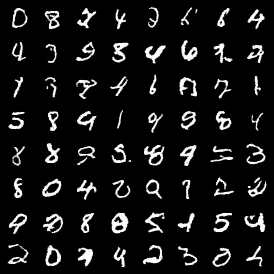

mnist_pixel_vs_ldm/pixel_ddpm_samples.png


In [9]:
# Sample from the pixel-space DDPM.
with torch.no_grad():
    pixel_samples = sample_ddpm(
        model=pixel_model,
        shape=(cfg.n_samples, 1, cfg.image_size, cfg.image_size),
        schedule=schedule,
        device=DEVICE,
    ).clamp(-1, 1)

pixel_path = Path(cfg.out_dir) / "pixel_ddpm_samples.png"
save_image((pixel_samples + 1) / 2, pixel_path, nrow=8)
display(Image.open(pixel_path))
print(pixel_path)

## 6. Autoencoder for latent diffusion

The autoencoder compresses each image:

```text
image:  1 x 32 x 32
latent: 4 x  8 x  8
```

That is a 4x reduction in scalar dimensionality:

```text
1 * 32 * 32 = 1024
4 *  8 *  8 = 256
```

This is intentionally simple and deterministic. A production latent diffusion model would usually use a stronger autoencoder or VAE trained on much larger data.

In [10]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_ch: int = 1, base_ch: int = 32, latent_ch: int = 4):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(base_ch, base_ch * 2, kernel_size=4, stride=2, padding=1),  # 32 -> 16
            nn.GroupNorm(valid_group_count(base_ch * 2), base_ch * 2),
            nn.SiLU(),
            nn.Conv2d(base_ch * 2, base_ch * 4, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.GroupNorm(valid_group_count(base_ch * 4), base_ch * 4),
            nn.SiLU(),
            nn.Conv2d(base_ch * 4, latent_ch, kernel_size=3, padding=1),
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(latent_ch, base_ch * 4, kernel_size=3, padding=1),
            nn.GroupNorm(valid_group_count(base_ch * 4), base_ch * 4),
            nn.SiLU(),
            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.GroupNorm(valid_group_count(base_ch * 2), base_ch * 2),
            nn.SiLU(),
            nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.GroupNorm(valid_group_count(base_ch), base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))


autoencoder = ConvAutoencoder(
    in_ch=1,
    base_ch=cfg.ae_base_ch,
    latent_ch=cfg.latent_ch,
).to(DEVICE)

with torch.no_grad():
    z = autoencoder.encode(torch.randn(4, 1, 32, 32, device=DEVICE))
    recon = autoencoder.decode(z)

print("latent shape:", z.shape)
print("reconstruction shape:", recon.shape)

latent shape: torch.Size([4, 4, 8, 8])
reconstruction shape: torch.Size([4, 1, 32, 32])


In [11]:
def train_autoencoder_epoch(
    autoencoder: ConvAutoencoder,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    device: torch.device,
) -> float:
    autoencoder.train()
    losses = []

    pbar = tqdm(loader, desc="train autoencoder", leave=False)
    for images, _labels in pbar:
        images = images.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=cfg.use_amp):
            recon = autoencoder(images)

            # L1 gives sharper reconstructions; MSE stabilizes pixel fidelity.
            loss_l1 = F.l1_loss(recon, images)
            loss_mse = F.mse_loss(recon, images)
            loss = loss_l1 + 0.5 * loss_mse

        scaler.scale(loss).backward()

        if cfg.grad_clip is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(autoencoder.parameters(), cfg.grad_clip)

        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return float(sum(losses) / len(losses))


ae_optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=cfg.lr)
ae_scaler = torch.amp.GradScaler(device="cuda", enabled=cfg.use_amp)

ae_losses = []
start = time.time()

for epoch in range(1, cfg.epochs_autoencoder + 1):
    loss = train_autoencoder_epoch(
        autoencoder=autoencoder,
        loader=train_loader,
        optimizer=ae_optimizer,
        scaler=ae_scaler,
        device=DEVICE,
    )
    ae_losses.append(loss)
    print(f"[autoencoder] epoch {epoch:03d} | loss={loss:.4f}")

elapsed = time.time() - start
print(f"autoencoder training time: {elapsed / 60:.2f} min")


train autoencoder:   0%|          | 0/234 [00:00<?, ?it/s]

[autoencoder] epoch 001 | loss=0.1117


train autoencoder:   0%|          | 0/234 [00:00<?, ?it/s]

[autoencoder] epoch 002 | loss=0.0243


train autoencoder:   0%|          | 0/234 [00:00<?, ?it/s]

KeyboardInterrupt: 

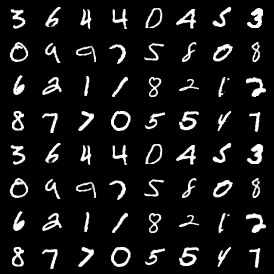

top rows: real images
bottom rows: reconstructions
mnist_pixel_vs_latent_diffusion_outputs/autoencoder_reconstructions.png


In [ ]:
# Autoencoder reconstruction check.
autoencoder.eval()

with torch.no_grad():
    images, _ = next(iter(train_loader))
    images = images[:32].to(DEVICE)
    recon = autoencoder(images)

comparison = torch.cat([images.cpu(), recon.cpu()], dim=0)
recon_path = Path(cfg.out_dir) / "autoencoder_reconstructions.png"
save_image((comparison.clamp(-1, 1) + 1) / 2, recon_path, nrow=8)
display(Image.open(recon_path))
print("top rows: real images")
print("bottom rows: reconstructions")
print(recon_path)

## 7. Latent normalization

Before training diffusion in latent space, estimate the latent mean and standard deviation.

This makes latent tensors closer to a standard normal scale, which usually stabilizes diffusion training.

In [13]:
@torch.no_grad()
def estimate_latent_stats(
    autoencoder: ConvAutoencoder,
    loader: DataLoader,
    device: torch.device,
    max_batches: int = 100,
) -> tuple[torch.Tensor, torch.Tensor]:
    autoencoder.eval()

    n = 0
    sum_z = None
    sum_z2 = None

    for batch_idx, (images, _labels) in enumerate(tqdm(loader, desc="estimate latent stats", leave=False)):
        if batch_idx >= max_batches:
            break

        images = images.to(device, non_blocking=True)
        z = autoencoder.encode(images)

        # Per-channel stats over batch and spatial dimensions.
        dims = (0, 2, 3)
        batch_sum = z.sum(dim=dims)
        batch_sum2 = (z ** 2).sum(dim=dims)
        count = z.shape[0] * z.shape[2] * z.shape[3]

        if sum_z is None:
            sum_z = batch_sum
            sum_z2 = batch_sum2
        else:
            sum_z += batch_sum
            sum_z2 += batch_sum2

        n += count

    mean = sum_z / n
    var = (sum_z2 / n) - mean ** 2
    std = torch.sqrt(var.clamp(min=1e-6))

    mean = mean.view(1, -1, 1, 1)
    std = std.view(1, -1, 1, 1)
    return mean, std


latent_mean, latent_std = estimate_latent_stats(autoencoder, train_loader, DEVICE)
print("latent mean:", latent_mean.flatten().detach().cpu())
print("latent std:", latent_std.flatten().detach().cpu())


@torch.no_grad()
def encode_scaled(images: torch.Tensor) -> torch.Tensor:
    z = autoencoder.encode(images)
    return (z - latent_mean) / latent_std


@torch.no_grad()
def decode_scaled(z_scaled: torch.Tensor) -> torch.Tensor:
    z = z_scaled * latent_std + latent_mean
    return autoencoder.decode(z)

estimate latent stats:   0%|          | 0/234 [00:00<?, ?it/s]

latent mean: tensor([ 0.0858, -0.2162,  0.5919,  0.7995])
latent std: tensor([0.3521, 0.2221, 0.1919, 0.2102])


## 8. Latent diffusion

Now the diffusion model trains on normalized latent tensors of shape `4 x 8 x 8`, not image tensors of shape `1 x 32 x 32`.

Sampling works as:

```text
noise -> latent denoising chain -> decoded image
```

In [ ]:
latent_model = TinyUNet(
    in_ch=cfg.latent_ch,
    base_ch=cfg.latent_unet_base_ch,
).to(DEVICE)

latent_optimizer = torch.optim.AdamW(latent_model.parameters(), lr=cfg.lr)
latent_scaler = torch.amp.GradScaler(device="cuda", enabled=cfg.use_amp)

# Freeze AE while training the latent diffusion model.
autoencoder.eval()
for p in autoencoder.parameters():
    p.requires_grad_(False)

latent_losses = []
start = time.time()

for epoch in range(1, cfg.epochs_latent + 1):
    loss = train_diffusion_epoch(
        model=latent_model,
        loader=train_loader,
        schedule=schedule,
        optimizer=latent_optimizer,
        scaler=latent_scaler,
        device=DEVICE,
        preprocess_batch=encode_scaled,
        desc=f"latent diffusion epoch {epoch}/{cfg.epochs_latent}",
    )
    latent_losses.append(loss)
    print(f"[latent] epoch {epoch:03d} | loss={loss:.4f}")

elapsed = time.time() - start
print(f"latent diffusion training time: {elapsed / 60:.2f} min")

torch.save(
    {
        "model": latent_model.state_dict(),
        "autoencoder": autoencoder.state_dict(),
        "latent_mean": latent_mean.detach().cpu(),
        "latent_std": latent_std.detach().cpu(),
        "cfg": cfg.__dict__,
        "losses": latent_losses,
    },
    Path(cfg.out_dir) / "latent_diffusion.pt",
)

sampling:   0%|          | 0/300 [00:00<?, ?it/s]

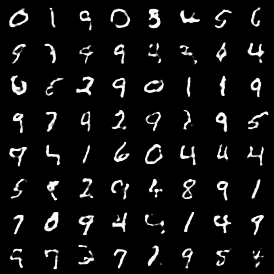

mnist_pixel_vs_latent_diffusion_outputs/latent_diffusion_samples.png


In [15]:
# Sample latents and decode them into image space.
with torch.no_grad():
    latent_samples = sample_ddpm(
        model=latent_model,
        shape=(cfg.n_samples, cfg.latent_ch, cfg.image_size // 4, cfg.image_size // 4),
        schedule=schedule,
        device=DEVICE,
    )
    decoded_samples = decode_scaled(latent_samples).clamp(-1, 1)

latent_path = Path(cfg.out_dir) / "latent_diffusion_samples.png"
save_image((decoded_samples + 1) / 2, latent_path, nrow=8)
display(Image.open(latent_path))
print(latent_path)

## 9. Compare losses and samples

Losses are not directly comparable as image quality metrics, because the two models denoise different spaces:

- pixel DDPM loss: noise prediction error on images,
- latent diffusion loss: noise prediction error on autoencoder latents.

Use these curves mainly to verify training behavior.

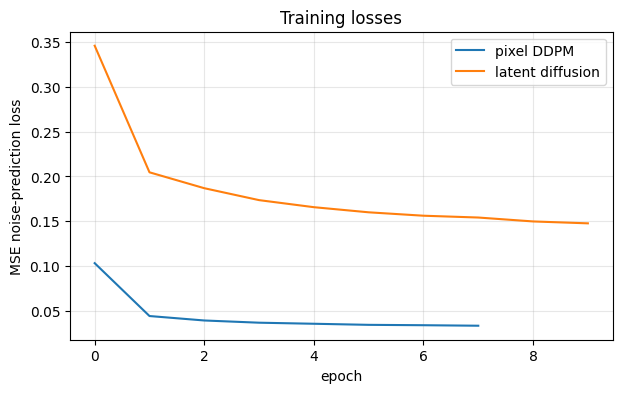

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(pixel_losses, label="pixel DDPM")
plt.plot(latent_losses, label="latent diffusion")
plt.xlabel("epoch")
plt.ylabel("MSE noise-prediction loss")
plt.title("Training losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

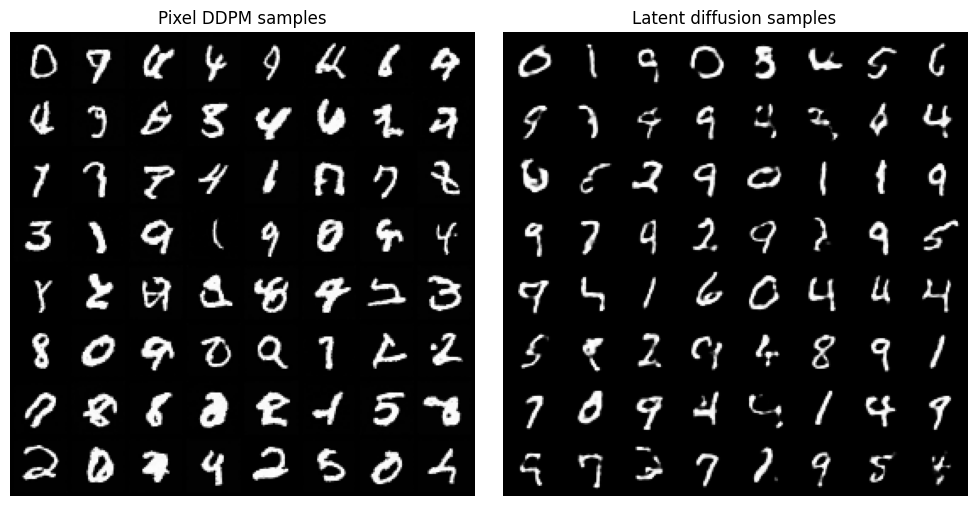

In [17]:
# Show final sample grids side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(Image.open(pixel_path), cmap="gray")
axes[0].set_title("Pixel DDPM samples")
axes[0].axis("off")

axes[1].imshow(Image.open(latent_path), cmap="gray")
axes[1].set_title("Latent diffusion samples")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 10. What to expect

For this small MNIST experiment:

| Aspect | Pixel diffusion | Latent diffusion |
|---|---:|---:|
| Denoising tensor | `1 x 32 x 32` | `4 x 8 x 8` |
| Scalar dimensionality | `1024` | `256` |
| Needs autoencoder | No | Yes |
| Sampling output | Direct image | Decode sampled latent |
| Failure mode | Slow/noisy image denoising | Autoencoder bottleneck artifacts |
| Main advantage | Conceptually simpler | Cheaper denoising space |

Practical interpretation:

- Pixel diffusion is the clean baseline.
- Latent diffusion should train and sample on smaller tensors, but final quality is bounded by the autoencoder.
- On MNIST, the benefit is modest because the images are already tiny.
- On high-resolution images, latent diffusion becomes much more useful because pixel-space diffusion is expensive.